In [1]:
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf
import statsmodels.api as sm

In [2]:
df = pd.read_csv("LEZGOOO.csv")
df.head()

,Unnamed: 0,_STATE,_AGE80,SEXVAR,_RACE,MENTHLTH,ECIGNOW2,USENOW3,_RFSMOK3,_RFBING6,...,LLCPWT,survey_date,survey_year,survey_month,Unemployment Rate,Death,flavor_ban,t21,tax,ecig_tax
0,0,1,42,1,1.0,0.0,2.0,3.0,2.0,1.0,...,1141.248720,2016-02-03,2016,2,5.9,0.0,0,0,0.675,0
1,1,1,70,2,1.0,10.0,4.0,3.0,2.0,1.0,...,531.192398,2016-02-03,2016,2,5.9,0.0,0,0,0.675,0
2,2,1,64,1,1.0,0.0,4.0,3.0,2.0,1.0,...,413.232363,2016-03-10,2016,3,5.9,0.0,0,0,0.675,0
3,3,1,51,1,1.0,30.0,4.0,3.0,2.0,1.0,...,243.946280,2016-03-02,2016,3,5.9,0.0,0,0,0.675,0
4,4,1,35,1,1.0,0.0,4.0,3.0,2.0,1.0,...,1339.733850,2016-01-10,2016,1,5.9,0.0,0,0,0.675,0


In [3]:
#AGE CONTROLLER and WEIGHT CHANGE
df= df[df['_AGE80']<30]

In [4]:
#add covid dummy
df["covid_dummy"] = df["survey_date"].between("2020-03-01", "2022-12-31").astype(int)

In [5]:
#adding marijuana legalization
# 1. Map of FIPS to legalization dates
rec_dates = {
    '6': '2018-01-01',
    '8': '2014-01-01',
    '25': '2014-01-01',
    '26': '2019-12-01',
    '13': '2020-01-01',
    '35': '2021-03-31',
    '32': '2017-07-01',
    '30': '2022-01-01',
    '9': '2021-07-01',
    '33': '2022-04-21',
    '34': '2022-04-01',
    '38': '2024-08-01',
    '23': '2023-07-01',
    '27': '2023-08-01',
    '29': '2023-12-08',
    '41': '2022-12-01',
}

# 2. Convert into DataFrame
rec_df = pd.DataFrame(list(rec_dates.items()), columns=['_STATE_STR', 'rec_mj_date'])
rec_df['_STATE'] = rec_df['_STATE_STR'].astype(int)
rec_df['rec_mj_date'] = pd.to_datetime(rec_df['rec_mj_date'])
rec_df.drop(columns=['_STATE_STR'], inplace=True)

# 3. Merge into main BRFSS df
df = df.merge(rec_df, on='_STATE', how='left')
df['survey_date'] = pd.to_datetime(df['survey_date'])

# 4. Create binary indicator
df['rec_marijuana'] = ((df['survey_date'] >= df['rec_mj_date']) & df['rec_mj_date'].notna()).astype(int)


In [6]:
#adding indoor smoke ban
ecig_ban_dates = {
    5:  '2016-06-09',   # California
    6:  '2019-07-01',   # Colorado
    7:  '2021-10-01',   # Connecticut
    8:  '2015-10-05',   # Delaware
    9:  '2016-11-18',   # DC
    13: '2016-01-01',   # Hawaii
    23: '2024-07-01',   # Maryland
    24: '2018-12-31',   # Massachusetts
    26: '2019-08-01',   # Minnesota
    33: '2010-07-11',   # New Jersey
    34: '2019-06-14',   # New Mexico
    35: '2017-11-22',   # New York
    37: '2012-12-06',   # North Dakota
    39: '2021-09-30',   # Ohio
    41: '2016-01-01',   # Oregon
    44: '2011-04-11',   # Puerto Rico
    45: '2018-07-01',   # Rhode Island
    47: '2018-07-01',   # South Dakota
    50: '2012-05-08',   # Utah
    51: '2016-07-01',   # Vermont
}
ban_df = pd.DataFrame(list(ecig_ban_dates.items()), columns=['_STATE', 'ecig_ban_date'])
ban_df['ecig_ban_date'] = pd.to_datetime(ban_df['ecig_ban_date'])

df = df.merge(ban_df, on='_STATE', how='left')
df['post_ecig_indoor_ban'] = ((df['survey_date'] >= df['ecig_ban_date']) & df['ecig_ban_date'].notna()).astype(int)


In [7]:
#WLS
if 'vapenow' in df.columns:
    del df['vapenow']
df['vapenow'] = df['ECIGNOW2'].replace({1:0, 4:0, 2:1, 3:0})
df['unemp'] = df['Unemployment Rate']
model_g1_vars = [
    'vapenow', 'flavor_ban', 'SEXVAR', '_RACE', '_AGE80', 'MENTHLTH',
    'unemp', 'Death', 't21', 'tax', 'ecig_tax', 'covid_dummy',
    'rec_marijuana', 'post_ecig_indoor_ban', '_STATE', 'survey_year', 'LLCPWT'
]
model_g1_df = df[model_g1_vars].dropna()
model_g1 = smf.wls(
    formula='vapenow ~ flavor_ban + C(SEXVAR) + C(_RACE) + _AGE80 + MENTHLTH + unemp + Death + t21 + tax + ecig_tax + covid_dummy + rec_marijuana + post_ecig_indoor_ban + C(_STATE) + C(survey_year)',
    data=model_g1_df,
    weights=model_g1_df['LLCPWT']
).fit(cov_type='cluster', cov_kwds={'groups': model_g1_df['_STATE']})

print(model_g1.summary())

                            WLS Regression Results                            
Dep. Variable:                vapenow   R-squared:                       0.033
Model:                            WLS   Adj. R-squared:                  0.032
Method:                 Least Squares   F-statistic:                     242.2
Date:                Sat, 26 Jul 2025   Prob (F-statistic):           2.47e-43
Time:                        14:15:13   Log-Likelihood:                -82406.
No. Observations:              184026   AIC:                         1.650e+05
Df Residuals:                  183950   BIC:                         1.657e+05
Df Model:                          75                                         
Covariance Type:              cluster                                         
                             coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------
Intercept                  0

/opt/anaconda3/lib/python3.11/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 75, but rank is 26
  warnings.warn('covariance of constraints does not have full '


In [8]:
#logit
logit_model_g1 = smf.logit(
    formula = 'vapenow ~ flavor_ban + C(SEXVAR) + C(_RACE) + _AGE80 + MENTHLTH + unemp + Death + t21 + tax + ecig_tax + covid_dummy + rec_marijuana + post_ecig_indoor_ban + C(_STATE) + C(survey_year)',
    data=model_g1_df  # same df as WLS
).fit()

print(logit_model_g1.summary())

Optimization terminated successfully.
         Current function value: 0.285291
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:                vapenow   No. Observations:               184026
Model:                          Logit   Df Residuals:                   183950
Method:                           MLE   Df Model:                           75
Date:                Sat, 26 Jul 2025   Pseudo R-squ.:                 0.04585
Time:                        14:15:22   Log-Likelihood:                -52501.
converged:                       True   LL-Null:                       -55024.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                             coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------
Intercept                 -1.4957      0.138    -10.864      0.000      -1.765      

In [9]:
mfx = logit_model_g1.get_margeff(at='overall')
print(mfx.summary())

        Logit Marginal Effects       
Dep. Variable:                vapenow
Method:                          dydx
At:                           overall
                            dy/dx    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------
C(SEXVAR)[T.2]            -0.0328      0.001    -23.833      0.000      -0.036      -0.030
C(_RACE)[T.2.0]           -0.0724      0.003    -20.703      0.000      -0.079      -0.066
C(_RACE)[T.3.0]           -0.0189      0.005     -3.853      0.000      -0.029      -0.009
C(_RACE)[T.4.0]           -0.0502      0.004    -13.401      0.000      -0.058      -0.043
C(_RACE)[T.5.0]            0.0059      0.007      0.797      0.426      -0.009       0.020
C(_RACE)[T.6.0]           -0.0181      0.010     -1.822      0.069      -0.037       0.001
C(_RACE)[T.7.0]           -0.0004      0.003     -0.130      0.897      -0.006       0.006
C(_RACE)[T.8.0]           -0.

In [10]:
# Get the summary table
summary_df = model_g1.summary2().tables[1]

# Filter only selected variables
subset = summary_df.loc[[
    "C(_STATE)[T.6]",
    "C(_STATE)[T.27]",
    "C(_STATE)[T.33]",
    "C(survey_year)[T.2020]",
    "flavor_ban",
    "unemp",
    "t21",
    "tax",
    "ecig_tax"
]]

# Round only numeric columns
numeric_cols = subset.select_dtypes(include='number').columns
subset[numeric_cols] = subset[numeric_cols].round(3)

# Convert to LaTeX
latex_table = subset.to_latex()
print(latex_table)



\begin{tabular}{lrrrrrr}
\toprule
 & Coef. & Std.Err. & z & P>|z| & [0.025 & 0.975] \\
\midrule
C(_STATE)[T.6] & -0.039000 & 0.018000 & -2.203000 & 0.028000 & -0.075000 & -0.004000 \\
C(_STATE)[T.27] & -0.030000 & 0.018000 & -1.653000 & 0.098000 & -0.066000 & 0.006000 \\
C(_STATE)[T.33] & -0.058000 & 0.006000 & -9.003000 & 0.000000 & -0.070000 & -0.045000 \\
C(survey_year)[T.2020] & 0.022000 & 0.018000 & 1.208000 & 0.227000 & -0.014000 & 0.057000 \\
flavor_ban & -0.016000 & 0.006000 & -2.893000 & 0.004000 & -0.027000 & -0.005000 \\
unemp & -0.001000 & 0.001000 & -0.803000 & 0.422000 & -0.004000 & 0.002000 \\
t21 & 0.022000 & 0.006000 & 3.852000 & 0.000000 & 0.011000 & 0.034000 \\
tax & -0.002000 & 0.003000 & -0.606000 & 0.544000 & -0.008000 & 0.004000 \\
ecig_tax & 0.002000 & 0.021000 & 0.101000 & 0.919000 & -0.038000 & 0.043000 \\
\bottomrule
\end{tabular}



In [11]:
#DONT TOUCH
df['USENOW3'] = df['USENOW3'].replace({3:0, 2:1})
df['_RFSMOK3'] = df['_RFSMOK3'].replace({1:0, 2:1})
df['_RFBING6'] = df['_RFBING6'].replace({1:0, 2:1})
df['MARIJAN1'] = (df['MARIJAN1'] != 0).astype(int)

In [63]:
from tabulate import tabulate

# Choose key variables
cols = ['ECIGNOW2', '_RFSMOK3', '_RFBING6', 'USENOW3', 'MARIJAN1', 'MENTHLTH', 'unemp', 'Death', 'tax', '_AGE80', 'SEXVAR', '_RACE']
summary = df[cols].describe(include='all').T

# Add count of unique values (especially useful for categorical vars)
summary['unique'] = df[cols].nunique()

# Round for LaTeX output
summary = summary[['count', 'mean', 'std', 'min', '25%', '50%', '75%', 'max', 'unique']].round(2)

# Output in LaTeX format
latex_table = tabulate(summary, headers='keys', tablefmt='latex')
print(latex_table)

\begin{tabular}{lrrrrrrrrr}
\hline
          &   count &   mean &    std &      min &   25\% &   50\% &    75\% &      max &   unique \\
\hline
 ECIGNOW2 &  196967 &   2.88 &   1.31 &     1    &  1    &   4   &   4    &     4    &        4 \\
 \_RFSMOK3 &  195959 &   0.15 &   0.36 &     0    &  0    &   0   &   0    &     1    &        2 \\
 \_RFBING6 &  190494 &   0.31 &   0.46 &     0    &  0    &   0   &   1    &     1    &        2 \\
 USENOW3  &  196777 &   0.06 &   0.23 &     0    &  0    &   0   &   0    &     1    &        2 \\
 MARIJAN1 &  196967 &   0.82 &   0.38 &     0    &  1    &   1   &   1    &     1    &        2 \\
 MENTHLTH &  193870 &   6.93 &   9.34 &     0    &  0    &   3   &  10    &    30    &       31 \\
 unemp    &  195234 &   4.15 &   1.74 &     1.7  &  3    &   3.8 &   4.7  &    30.5  &      139 \\
 Death    &  196967 & 281.74 & 673.8  & -3488    &  0    &  16   & 283    & 18664    &      832 \\
 tax      &  189876 &   1.97 &   1.18 &     0.17 &  1.03 &   1

In [95]:
#Grouping into age groups and mental health (18-21, 22-25, 26-30, 30+)
df['age_group'] = pd.cut(
    df['_AGE80'],  # replace with actual column name if different
    bins=[17, 21, 25, 29, 120],
    labels=['18–21', '22–25', '26–29', '30+']
)
print(df['age_group'].value_counts(dropna=False).sort_index())

age_group
18–21    11518
22–25    12285
26–29        0
30+          0
NaN      19094
Name: count, dtype: int64


In [13]:
df['mh_group'] = pd.cut(
    df['MENTHLTH'],
    bins=[-1, 0, 9, 30],
    labels=['Good (0 days)', 'Moderate (1–9 days)', 'Frequent (10+ days)']
)
print(df['mh_group'].value_counts(dropna=False).sort_index())

mh_group
Good (0 days)          76524
Moderate (1–9 days)    60862
Frequent (10+ days)    56484
NaN                     3097
Name: count, dtype: int64


In [14]:
flavor_ban_dates = {
    '06': '2022-01-01',
    '25': '2019-09-24',
    '36': '2020-05-18',
    '34': '2020-01-01',
    '44': '2020-03-01',
    '24': '2021-01-01',
    '23': '2021-01-01',
    '49': '2020-01-01',
}

ban_df = pd.DataFrame(list(flavor_ban_dates.items()), columns=['_STATE_STR', 'flavor_ban_date'])
ban_df['flavor_ban_date'] = pd.to_datetime(ban_df['flavor_ban_date'])
ban_df['_STATE'] = ban_df['_STATE_STR'].astype(int)
ban_df.drop(columns=['_STATE_STR'], inplace=True)

df = df.merge(ban_df, on='_STATE', how='left')
df['survey_date'] = pd.to_datetime(df['survey_date'])
df['event_time'] = ((df['survey_date'] - df['flavor_ban_date']).dt.days / 365).round().astype('Int64')

In [15]:
#for event study
df_e = df[df['flavor_ban_date'].notna()]

# Optional: restrict to a sensible window for plotting
df_e = df_e[df_e['event_time'].notna() & df_e['event_time'].between(-3, 3)]

# Convert to categorical for regression and drop -1 as reference period
df_e['event_time'] = df_e['event_time'].astype('category')
df_e['event_time'] = df_e['event_time'].cat.remove_categories([-1])
#df_e = df_e.dropna()


In [16]:
model_g1e_vars = [
    'vapenow', 'event_time', 'flavor_ban', 'SEXVAR', '_RACE', '_AGE80', 'MENTHLTH',
    'unemp', 'Death', 't21', 'tax', 'ecig_tax', 'covid_dummy',
    'rec_marijuana', 'post_ecig_indoor_ban', '_STATE', 'survey_year', 'LLCPWT'
]
model_g1e_df_e = df_e[model_g1e_vars].dropna()
model_g1e = smf.wls(
    formula='vapenow ~ C(event_time) + _AGE80 + C(SEXVAR) + C(_RACE) + MENTHLTH + unemp + Death + t21 + tax + ecig_tax + covid_dummy + rec_marijuana + post_ecig_indoor_ban + C(_STATE) + C(survey_year)',
    data=model_g1e_df_e,
    weights=model_g1e_df_e['LLCPWT']
).fit(cov_type='cluster', cov_kwds={'groups': model_g1e_df_e['_STATE']})

print(model_g1e.summary())


                            WLS Regression Results                            
Dep. Variable:                vapenow   R-squared:                       0.034
Model:                            WLS   Adj. R-squared:                  0.033
Method:                 Least Squares   F-statistic:                 7.140e+11
Date:                Sat, 26 Jul 2025   Prob (F-statistic):           4.69e-41
Time:                        14:17:53   Log-Likelihood:                -11728.
No. Observations:               33731   AIC:                         2.353e+04
Df Residuals:                   33694   BIC:                         2.384e+04
Df Model:                          36                                         
Covariance Type:              cluster                                         
                             coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------
Intercept                  0

/opt/anaconda3/lib/python3.11/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 37, but rank is 10
  warnings.warn('covariance of constraints does not have full '


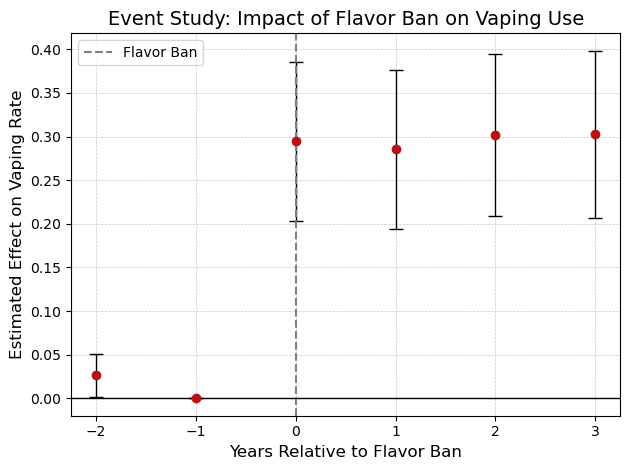

In [17]:
import matplotlib.pyplot as plt

# Extract event_time coefficients and standard errors
event_coefs = model_g1e.params.filter(like='C(event_time)')
event_se = model_g1e.bse.filter(like='C(event_time)')

# Extract the integer event time (e.g., -2, 0, 1, ...)
event_index = [int(i.split('[T.')[1].split(']')[0]) for i in event_coefs.index]
event_effects = list(event_coefs.values)
event_errors = [1.96 * s for s in event_se]

# Add the reference period (t = -1) as zero
event_index = [-1] + event_index
event_effects = [0] + event_effects
event_errors = [0] + event_errors  # No CI bar for the reference period

# Sort all by event time
sorted_idx = sorted(range(len(event_index)), key=lambda i: event_index[i])
event_index = [event_index[i] for i in sorted_idx]
event_effects = [event_effects[i] for i in sorted_idx]
event_errors = [event_errors[i] for i in sorted_idx]

# Plot
plt.errorbar(
    event_index,
    event_effects,
    yerr=event_errors,
    fmt='o',
    color="#BA1111",        # red dots
    ecolor='black',         # Black error bars
    capsize=5,
    linewidth=1,
    markersize=6
)

# Reference lines
plt.axvline(x=0, color='gray', linestyle='--', linewidth=1.5, label='Flavor Ban')
plt.axhline(y=0, color='black', linewidth=1)

# Labels and formatting
plt.xlabel('Years Relative to Flavor Ban', fontsize=12)
plt.ylabel('Estimated Effect on Vaping Rate', fontsize=12)
plt.title('Event Study: Impact of Flavor Ban on Vaping Use', fontsize=14)
plt.xticks(event_index)
plt.legend()
plt.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)
plt.tight_layout()

plt.show()

In [18]:
#USENOW3
model_g2_vars = [
    'USENOW3', 'flavor_ban', 'SEXVAR', '_RACE', '_AGE80', 'MENTHLTH',
    'unemp', 'Death', 't21', 'tax', 'ecig_tax', 'covid_dummy',
    'rec_marijuana', 'post_ecig_indoor_ban', '_STATE', 'survey_year', 'LLCPWT'
]
model_g2_df = df[model_g2_vars].dropna()
model_g2 = smf.wls(
    formula='USENOW3 ~ flavor_ban + _AGE80 + C(SEXVAR) + C(_RACE) + MENTHLTH + unemp + Death + t21 + tax + ecig_tax + covid_dummy + rec_marijuana + post_ecig_indoor_ban + C(_STATE) + C(survey_year)',
    data=model_g2_df,
    weights=model_g2_df['LLCPWT']
).fit(cov_type='cluster', cov_kwds={'groups': model_g2_df['_STATE']})

print(model_g2.summary())

                            WLS Regression Results                            
Dep. Variable:                USENOW3   R-squared:                       0.034
Model:                            WLS   Adj. R-squared:                  0.034
Method:                 Least Squares   F-statistic:                     923.0
Date:                Sat, 26 Jul 2025   Prob (F-statistic):           1.77e-57
Time:                        14:18:03   Log-Likelihood:                -36874.
No. Observations:              183864   AIC:                         7.390e+04
Df Residuals:                  183788   BIC:                         7.467e+04
Df Model:                          75                                         
Covariance Type:              cluster                                         
                             coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------
Intercept                  0

/opt/anaconda3/lib/python3.11/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 75, but rank is 26
  warnings.warn('covariance of constraints does not have full '


In [20]:
model_g2e_vars = [
    'USENOW3', 'event_time', 'flavor_ban', 'SEXVAR', '_RACE', '_AGE80', 'MENTHLTH',
    'unemp', 'Death', 't21', 'tax', 'ecig_tax', 'covid_dummy',
    'rec_marijuana', 'post_ecig_indoor_ban', '_STATE', 'survey_year', 'LLCPWT'
]
model_g2e_df_e = df_e[model_g2e_vars].dropna()
model_g2e = smf.wls(
    formula='USENOW3 ~ C(event_time) + _AGE80 + C(SEXVAR) + C(_RACE) + MENTHLTH + unemp + Death + t21 + tax + ecig_tax + covid_dummy + rec_marijuana + post_ecig_indoor_ban + C(_STATE) + C(survey_year)',
    data=model_g2e_df_e,
    weights=model_g2e_df_e['LLCPWT']
).fit(cov_type='cluster', cov_kwds={'groups': model_g2e_df_e['_STATE']})

print(model_g2e.summary())

                            WLS Regression Results                            
Dep. Variable:                USENOW3   R-squared:                       0.015
Model:                            WLS   Adj. R-squared:                  0.014
Method:                 Least Squares   F-statistic:                -1.138e+12
Date:                Sat, 26 Jul 2025   Prob (F-statistic):               1.00
Time:                        14:18:37   Log-Likelihood:                -715.38
No. Observations:               33691   AIC:                             1505.
Df Residuals:                   33654   BIC:                             1816.
Df Model:                          36                                         
Covariance Type:              cluster                                         
                             coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------
Intercept                  0

/opt/anaconda3/lib/python3.11/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 37, but rank is 9
  warnings.warn('covariance of constraints does not have full '


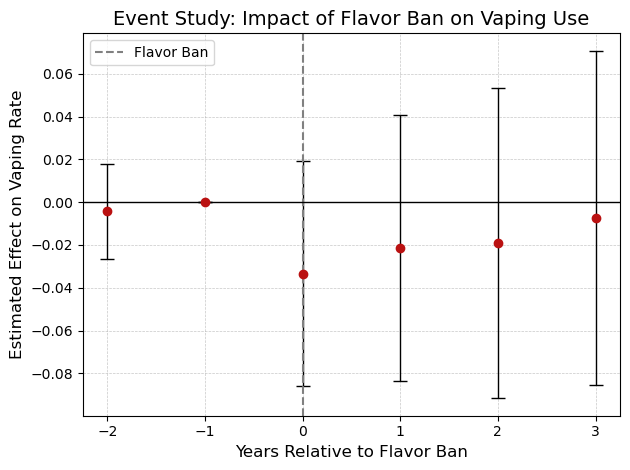

In [21]:
# Extract event_time coefficients and standard errors
event_coefs = model_g2e.params.filter(like='C(event_time)')
event_se = model_g2e.bse.filter(like='C(event_time)')

# Extract the integer event time (e.g., -2, 0, 1, ...)
event_index = [int(i.split('[T.')[1].split(']')[0]) for i in event_coefs.index]
event_effects = list(event_coefs.values)
event_errors = [1.96 * s for s in event_se]

# Add the reference period (t = -1) as zero
event_index = [-1] + event_index
event_effects = [0] + event_effects
event_errors = [0] + event_errors  # No CI bar for the reference period

# Sort all by event time
sorted_idx = sorted(range(len(event_index)), key=lambda i: event_index[i])
event_index = [event_index[i] for i in sorted_idx]
event_effects = [event_effects[i] for i in sorted_idx]
event_errors = [event_errors[i] for i in sorted_idx]

# Plot
plt.errorbar(
    event_index,
    event_effects,
    yerr=event_errors,
    fmt='o',
    color="#BA1111",        # red dots
    ecolor='black',         # Black error bars
    capsize=5,
    linewidth=1,
    markersize=6
)

# Reference lines
plt.axvline(x=0, color='gray', linestyle='--', linewidth=1.5, label='Flavor Ban')
plt.axhline(y=0, color='black', linewidth=1)

# Labels and formatting
plt.xlabel('Years Relative to Flavor Ban', fontsize=12)
plt.ylabel('Estimated Effect on Vaping Rate', fontsize=12)
plt.title('Event Study: Impact of Flavor Ban on Vaping Use', fontsize=14)
plt.xticks(event_index)
plt.legend()
plt.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)
plt.tight_layout()

plt.show()

In [22]:
model_g3_vars = [
    '_RFSMOK3', 'flavor_ban', 'SEXVAR', '_RACE', '_AGE80', 'MENTHLTH',
    'unemp', 'Death', 't21', 'tax', 'ecig_tax', 'covid_dummy',
    'rec_marijuana', 'post_ecig_indoor_ban', '_STATE', 'survey_year', 'LLCPWT'
]
model_g3_df = df[model_g3_vars].dropna()

model_g3 = smf.wls(
    formula='_RFSMOK3 ~ flavor_ban + _AGE80 + C(SEXVAR) + C(_RACE) + MENTHLTH + unemp + Death + t21 + tax + ecig_tax + covid_dummy + rec_marijuana + post_ecig_indoor_ban + C(_STATE) + C(survey_year)',
    data=model_g3_df,
    weights=model_g3_df['LLCPWT']
).fit(cov_type='cluster', cov_kwds={'groups': model_g3_df['_STATE']})

print(model_g3.summary())

                            WLS Regression Results                            
Dep. Variable:               _RFSMOK3   R-squared:                       0.124
Model:                            WLS   Adj. R-squared:                  0.124
Method:                 Least Squares   F-statistic:                     1234.
Date:                Sat, 26 Jul 2025   Prob (F-statistic):           1.46e-60
Time:                        14:18:52   Log-Likelihood:            -1.1677e+05
No. Observations:              183134   AIC:                         2.337e+05
Df Residuals:                  183058   BIC:                         2.345e+05
Df Model:                          75                                         
Covariance Type:              cluster                                         
                             coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------
Intercept                  0

/opt/anaconda3/lib/python3.11/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 75, but rank is 26
  warnings.warn('covariance of constraints does not have full '


In [23]:
#smoking logit
logit_model_g3 = smf.logit(
    formula = '_RFSMOK3 ~ flavor_ban + C(SEXVAR) + C(_RACE) + _AGE80 + MENTHLTH + unemp + Death + t21 + tax + ecig_tax + covid_dummy + rec_marijuana + post_ecig_indoor_ban + C(_STATE) + C(survey_year)',
    data=model_g3_df  # same df as WLS
).fit()

print(logit_model_g3.summary())


Optimization terminated successfully.
         Current function value: 0.370912
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:               _RFSMOK3   No. Observations:               183134
Model:                          Logit   Df Residuals:                   183058
Method:                           MLE   Df Model:                           75
Date:                Sat, 26 Jul 2025   Pseudo R-squ.:                  0.1421
Time:                        14:19:10   Log-Likelihood:                -67927.
converged:                       True   LL-Null:                       -79176.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                             coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------
Intercept                 -3.5866      0.097    -36.881      0.000      -3.777      

In [24]:
mfx = logit_model_g3.get_margeff(at='overall')
print(mfx.summary())

        Logit Marginal Effects       
Dep. Variable:               _RFSMOK3
Method:                          dydx
At:                           overall
                            dy/dx    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------
C(SEXVAR)[T.2]            -0.0331      0.002    -20.311      0.000      -0.036      -0.030
C(_RACE)[T.2.0]           -0.0277      0.003     -8.236      0.000      -0.034      -0.021
C(_RACE)[T.3.0]            0.0809      0.005     16.884      0.000       0.072       0.090
C(_RACE)[T.4.0]           -0.0452      0.005     -9.752      0.000      -0.054      -0.036
C(_RACE)[T.5.0]            0.0347      0.010      3.483      0.000       0.015       0.054
C(_RACE)[T.6.0]            0.0237      0.011      2.237      0.025       0.003       0.044
C(_RACE)[T.7.0]            0.0246      0.004      6.435      0.000       0.017       0.032
C(_RACE)[T.8.0]           -0.

In [25]:
model_g3e_vars = [
    '_RFSMOK3', 'event_time', 'flavor_ban', 'SEXVAR', '_RACE', '_AGE80', 'MENTHLTH',
    'unemp', 'Death', 't21', 'tax', 'ecig_tax', 'covid_dummy',
    'rec_marijuana', 'post_ecig_indoor_ban', '_STATE', 'survey_year', 'LLCPWT'
]
model_g3e_df_e = df_e[model_g3e_vars].dropna()
model_g3e = smf.wls(
    formula='_RFSMOK3 ~ C(event_time) + _AGE80 + C(SEXVAR) + C(_RACE) + MENTHLTH + unemp + Death + t21 + tax + ecig_tax + covid_dummy + rec_marijuana + post_ecig_indoor_ban + C(_STATE) + C(survey_year)',
    data=model_g3e_df_e,
    weights=model_g3e_df_e['LLCPWT']
).fit(cov_type='cluster', cov_kwds={'groups': model_g3e_df_e['_STATE']})

print(model_g3e.summary())

                            WLS Regression Results                            
Dep. Variable:               _RFSMOK3   R-squared:                       0.092
Model:                            WLS   Adj. R-squared:                  0.091
Method:                 Least Squares   F-statistic:                 9.239e+09
Date:                Sat, 26 Jul 2025   Prob (F-statistic):           2.04e-34
Time:                        14:22:11   Log-Likelihood:                -16013.
No. Observations:               33528   AIC:                         3.210e+04
Df Residuals:                   33491   BIC:                         3.241e+04
Df Model:                          36                                         
Covariance Type:              cluster                                         
                             coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------
Intercept                  0

/opt/anaconda3/lib/python3.11/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 37, but rank is 9
  warnings.warn('covariance of constraints does not have full '


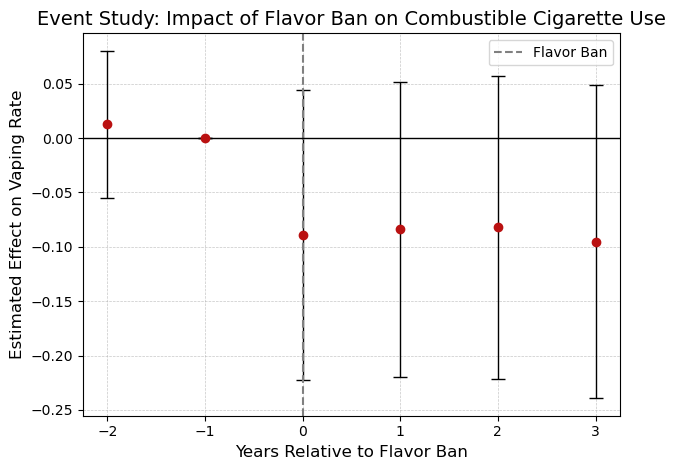

In [79]:
# Extract event_time coefficients and standard errors
event_coefs = model_g3e.params.filter(like='C(event_time)')
event_se = model_g3e.bse.filter(like='C(event_time)')

# Extract the integer event time (e.g., -2, 0, 1, ...)
event_index = [int(i.split('[T.')[1].split(']')[0]) for i in event_coefs.index]
event_effects = list(event_coefs.values)
event_errors = [1.96 * s for s in event_se]

# Add the reference period (t = -1) as zero
event_index = [-1] + event_index
event_effects = [0] + event_effects
event_errors = [0] + event_errors  # No CI bar for the reference period

# Sort all by event time
sorted_idx = sorted(range(len(event_index)), key=lambda i: event_index[i])
event_index = [event_index[i] for i in sorted_idx]
event_effects = [event_effects[i] for i in sorted_idx]
event_errors = [event_errors[i] for i in sorted_idx]

# Plot
plt.errorbar(
    event_index,
    event_effects,
    yerr=event_errors,
    fmt='o',
    color="#BA1111",        # red dots
    ecolor='black',         # Black error bars
    capsize=5,
    linewidth=1,
    markersize=6
)

# Reference lines
plt.axvline(x=0, color='gray', linestyle='--', linewidth=1.5, label='Flavor Ban')
plt.axhline(y=0, color='black', linewidth=1)

# Labels and formatting
plt.xlabel('Years Relative to Flavor Ban', fontsize=12)
plt.ylabel('Estimated Effect on Vaping Rate', fontsize=12)
plt.title('Event Study: Impact of Flavor Ban on Combustible Cigarette Use', fontsize=14)
plt.xticks(event_index)
plt.legend()
plt.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)
plt.tight_layout()

plt.show()

In [27]:
model_g4_vars = [
    '_RFBING6', 'flavor_ban', 'SEXVAR', '_RACE', '_AGE80', 'MENTHLTH',
    'unemp', 'Death', 't21', 'tax', 'ecig_tax', 'covid_dummy',
    'rec_marijuana', 'post_ecig_indoor_ban', '_STATE', 'survey_year', 'LLCPWT'
]
model_g4_df = df[model_g4_vars].dropna()
model_g4 = smf.wls(
    formula='_RFBING6 ~ flavor_ban + _AGE80 + C(SEXVAR) + C(_RACE) + MENTHLTH + unemp + Death + t21 + tax + ecig_tax + covid_dummy + rec_marijuana + post_ecig_indoor_ban + C(_STATE) + C(survey_year)',
    data=model_g4_df,
    weights=model_g4_df['LLCPWT']
).fit(cov_type='cluster', cov_kwds={'groups': model_g4_df['_STATE']})

print(model_g4.summary())

                            WLS Regression Results                            
Dep. Variable:               _RFBING6   R-squared:                       0.055
Model:                            WLS   Adj. R-squared:                  0.055
Method:                 Least Squares   F-statistic:                     2542.
Date:                Sat, 26 Jul 2025   Prob (F-statistic):           3.09e-68
Time:                        14:22:25   Log-Likelihood:            -1.6344e+05
No. Observations:              178286   AIC:                         3.270e+05
Df Residuals:                  178210   BIC:                         3.278e+05
Df Model:                          75                                         
Covariance Type:              cluster                                         
                             coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------
Intercept                  0

/opt/anaconda3/lib/python3.11/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 75, but rank is 26
  warnings.warn('covariance of constraints does not have full '


In [28]:
model_g4e_vars = [
    '_RFBING6', 'event_time', 'flavor_ban', 'SEXVAR', '_RACE', '_AGE80', 'MENTHLTH',
    'unemp', 'Death', 't21', 'tax', 'ecig_tax', 'covid_dummy',
    'rec_marijuana', 'post_ecig_indoor_ban', '_STATE', 'survey_year', 'LLCPWT'
]
model_g4e_df_e = df_e[model_g4e_vars].dropna()
model_g4e = smf.wls(
    formula='_RFBING6 ~ C(event_time) + _AGE80 + C(SEXVAR) + C(_RACE) + MENTHLTH + unemp + Death + t21 + tax + ecig_tax + covid_dummy + rec_marijuana + post_ecig_indoor_ban + C(_STATE) + C(survey_year)',
    data=model_g4e_df_e,
    weights=model_g4e_df_e['LLCPWT']
).fit(cov_type='cluster', cov_kwds={'groups': model_g4e_df_e['_STATE']})

print(model_g4e.summary())

                            WLS Regression Results                            
Dep. Variable:               _RFBING6   R-squared:                       0.069
Model:                            WLS   Adj. R-squared:                  0.068
Method:                 Least Squares   F-statistic:                -2.224e+12
Date:                Sat, 26 Jul 2025   Prob (F-statistic):               1.00
Time:                        14:22:29   Log-Likelihood:                -29360.
No. Observations:               32608   AIC:                         5.879e+04
Df Residuals:                   32571   BIC:                         5.910e+04
Df Model:                          36                                         
Covariance Type:              cluster                                         
                             coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------
Intercept                  0

/opt/anaconda3/lib/python3.11/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 37, but rank is 9
  warnings.warn('covariance of constraints does not have full '


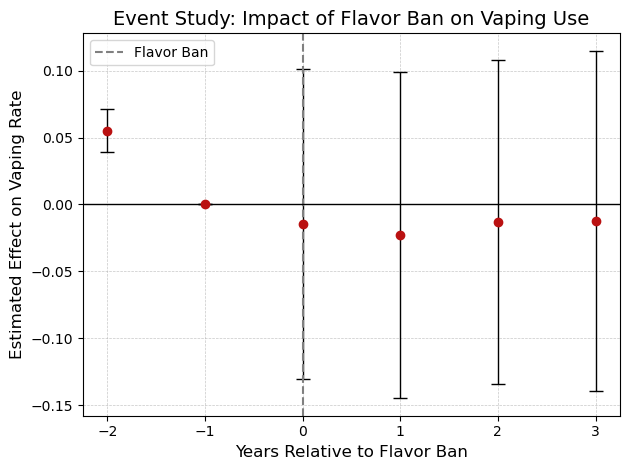

In [29]:
# Extract event_time coefficients and standard errors
event_coefs = model_g4e.params.filter(like='C(event_time)')
event_se = model_g4e.bse.filter(like='C(event_time)')

# Extract the integer event time (e.g., -2, 0, 1, ...)
event_index = [int(i.split('[T.')[1].split(']')[0]) for i in event_coefs.index]
event_effects = list(event_coefs.values)
event_errors = [1.96 * s for s in event_se]

# Add the reference period (t = -1) as zero
event_index = [-1] + event_index
event_effects = [0] + event_effects
event_errors = [0] + event_errors  # No CI bar for the reference period

# Sort all by event time
sorted_idx = sorted(range(len(event_index)), key=lambda i: event_index[i])
event_index = [event_index[i] for i in sorted_idx]
event_effects = [event_effects[i] for i in sorted_idx]
event_errors = [event_errors[i] for i in sorted_idx]

# Plot
plt.errorbar(
    event_index,
    event_effects,
    yerr=event_errors,
    fmt='o',
    color="#BA1111",        # red dots
    ecolor='black',         # Black error bars
    capsize=5,
    linewidth=1,
    markersize=6
)

# Reference lines
plt.axvline(x=0, color='gray', linestyle='--', linewidth=1.5, label='Flavor Ban')
plt.axhline(y=0, color='black', linewidth=1)

# Labels and formatting
plt.xlabel('Years Relative to Flavor Ban', fontsize=12)
plt.ylabel('Estimated Effect on Vaping Rate', fontsize=12)
plt.title('Event Study: Impact of Flavor Ban on Vaping Use', fontsize=14)
plt.xticks(event_index)
plt.legend()
plt.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)
plt.tight_layout()

plt.show()

In [30]:
model_g5_vars = [
    'MARIJAN1', 'flavor_ban', 'SEXVAR', '_RACE', '_AGE80', 'MENTHLTH',
    'unemp', 'Death', 't21', 'tax', 'ecig_tax', 'covid_dummy',
    'rec_marijuana', 'post_ecig_indoor_ban', '_STATE', 'survey_year', 'LLCPWT'
]
model_g5_df = df[model_g5_vars].dropna()
model_g5 = smf.wls(
    formula='MARIJAN1 ~ flavor_ban + _AGE80 + C(SEXVAR) + C(_RACE) + MENTHLTH + unemp + Death + t21 + tax + ecig_tax + covid_dummy + rec_marijuana + post_ecig_indoor_ban + C(_STATE) + C(survey_year)',
    data=model_g5_df,
    weights=model_g5_df['LLCPWT']
).fit(cov_type='cluster', cov_kwds={'groups': model_g5_df['_STATE']})

print(model_g5.summary())

                            WLS Regression Results                            
Dep. Variable:               MARIJAN1   R-squared:                       0.261
Model:                            WLS   Adj. R-squared:                  0.261
Method:                 Least Squares   F-statistic:                 1.283e+04
Date:                Sat, 26 Jul 2025   Prob (F-statistic):           1.87e-85
Time:                        14:25:57   Log-Likelihood:                -87767.
No. Observations:              184026   AIC:                         1.757e+05
Df Residuals:                  183950   BIC:                         1.765e+05
Df Model:                          75                                         
Covariance Type:              cluster                                         
                             coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------
Intercept                  1

/opt/anaconda3/lib/python3.11/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 75, but rank is 26
  warnings.warn('covariance of constraints does not have full '


In [31]:
model_g5e_vars = [
    'MARIJAN1', 'event_time', 'flavor_ban', 'SEXVAR', '_RACE', '_AGE80', 'MENTHLTH',
    'unemp', 'Death', 't21', 'tax', 'ecig_tax', 'covid_dummy',
    'rec_marijuana', 'post_ecig_indoor_ban', '_STATE', 'survey_year', 'LLCPWT'
]
model_g5e_df_e = df_e[model_g5e_vars].dropna()
model_g5e = smf.wls(
    formula='MARIJAN1 ~ C(event_time) + _AGE80 + C(SEXVAR) + C(_RACE) + MENTHLTH + unemp + Death + t21 + tax + ecig_tax + covid_dummy + rec_marijuana + post_ecig_indoor_ban + C(_STATE) + C(survey_year)',
    data=model_g5e_df_e,
    weights=model_g5e_df_e['LLCPWT']
).fit(cov_type='cluster', cov_kwds={'groups': model_g5e_df_e['_STATE']})

print(model_g5e.summary())

                            WLS Regression Results                            
Dep. Variable:               MARIJAN1   R-squared:                       0.489
Model:                            WLS   Adj. R-squared:                  0.489
Method:                 Least Squares   F-statistic:                -1.975e+12
Date:                Sat, 26 Jul 2025   Prob (F-statistic):               1.00
Time:                        14:26:00   Log-Likelihood:                 506.05
No. Observations:               33731   AIC:                            -938.1
Df Residuals:                   33694   BIC:                            -626.3
Df Model:                          36                                         
Covariance Type:              cluster                                         
                             coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------
Intercept                 -0

/opt/anaconda3/lib/python3.11/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 37, but rank is 9
  warnings.warn('covariance of constraints does not have full '


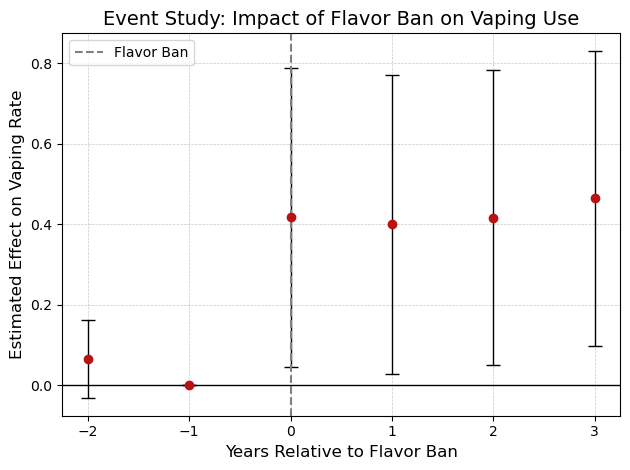

In [32]:
# Extract event_time coefficients and standard errors
event_coefs = model_g5e.params.filter(like='C(event_time)')
event_se = model_g5e.bse.filter(like='C(event_time)')

# Extract the integer event time (e.g., -2, 0, 1, ...)
event_index = [int(i.split('[T.')[1].split(']')[0]) for i in event_coefs.index]
event_effects = list(event_coefs.values)
event_errors = [1.96 * s for s in event_se]

# Add the reference period (t = -1) as zero
event_index = [-1] + event_index
event_effects = [0] + event_effects
event_errors = [0] + event_errors  # No CI bar for the reference period

# Sort all by event time
sorted_idx = sorted(range(len(event_index)), key=lambda i: event_index[i])
event_index = [event_index[i] for i in sorted_idx]
event_effects = [event_effects[i] for i in sorted_idx]
event_errors = [event_errors[i] for i in sorted_idx]

# Plot
plt.errorbar(
    event_index,
    event_effects,
    yerr=event_errors,
    fmt='o',
    color="#BA1111",        # red dots
    ecolor='black',         # Black error bars
    capsize=5,
    linewidth=1,
    markersize=6
)

# Reference lines
plt.axvline(x=0, color='gray', linestyle='--', linewidth=1.5, label='Flavor Ban')
plt.axhline(y=0, color='black', linewidth=1)

# Labels and formatting
plt.xlabel('Years Relative to Flavor Ban', fontsize=12)
plt.ylabel('Estimated Effect on Vaping Rate', fontsize=12)
plt.title('Event Study: Impact of Flavor Ban on Vaping Use', fontsize=14)
plt.xticks(event_index)
plt.legend()
plt.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)
plt.tight_layout()

plt.show()

<Figure size 1000x600 with 0 Axes>

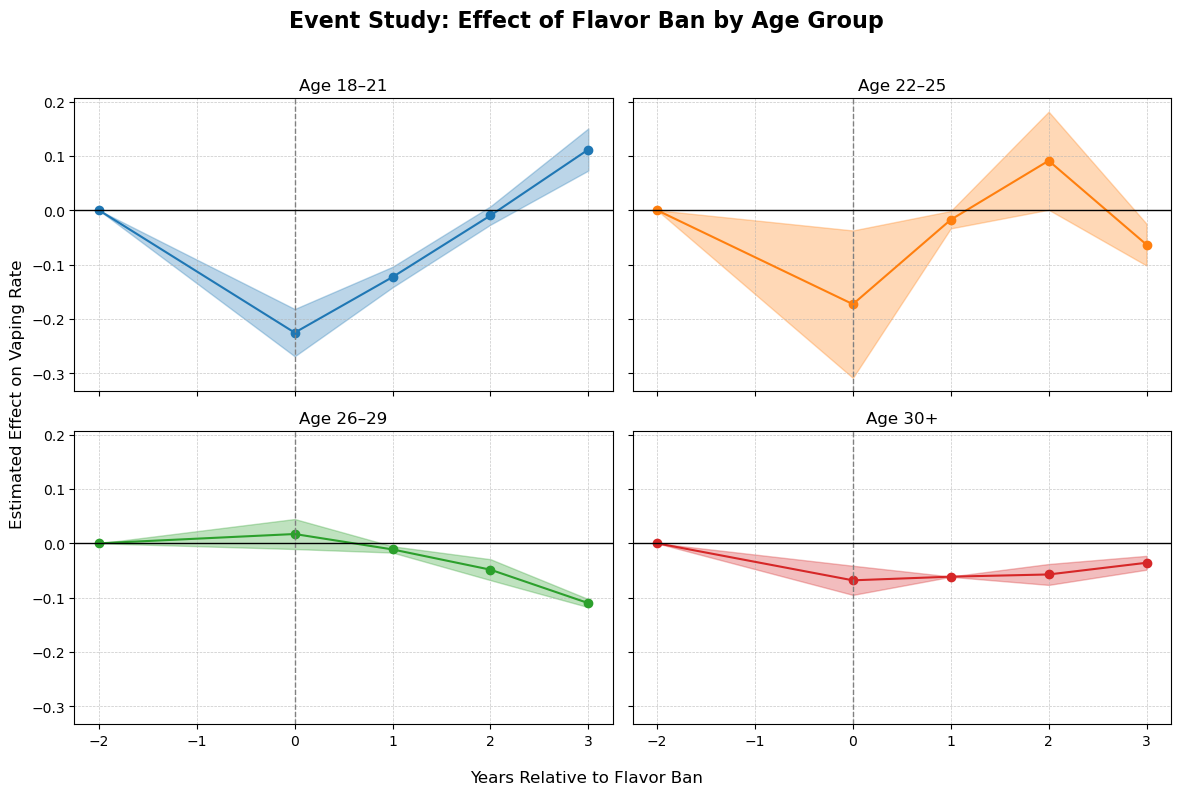

In [ ]:
#   SKIP FOR NOW

age_labels = ['18–21', '22–25', '26–29', '30+']
#age group study
results_by_age = {}

# Loop over age groups
for label in age_labels:
    df_sub = df_e[(df_e['age_group'] == label) & df_e['event_time'].notna()].copy()
    
    if df_sub.empty:
        print(f"Skipping group {label} – no data")
        continue

    model = smf.wls(
        formula='vapenow ~ C(event_time) + C(SEXVAR) + C(_RACE) + MENTHLTH + unemp + Death + t21 + tax + ecig_tax + covid_dummy + rec_marijuana + post_ecig_indoor_ban + C(_STATE) + C(survey_year)',
        data=df_sub,
        weights=df_sub['LLCPWT']
    ).fit(cov_type='cluster', cov_kwds={'groups': df_sub['_STATE']})
    
    coefs = model.params.filter(like='C(event_time)')
    ses = model.bse.filter(like='C(event_time)')
    times = [int(term.split('[')[1].split(']')[0].replace('T.', '')) for term in coefs.index]
    
    results_by_age[label] = (times, coefs.values, ses.values)
plt.figure(figsize=(10, 6))

# Color cycle for better contrast
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True, sharey=True)
axes = axes.flatten()

for i, (label, (x, y, se)) in enumerate(sorted(results_by_age.items())):
    ax = axes[i]
    x = np.array(x)
    y = np.array(y)
    se = np.array(se)
    
    # Plot main line
    ax.plot(x, y, marker='o', label=label, color=colors[i])
    
    # Add confidence band
    ax.fill_between(x, y - 1.96*se, y + 1.96*se, alpha=0.3, color=colors[i])
    
    # Add reference lines
    ax.axvline(x=0, color='gray', linestyle='--', linewidth=1)
    ax.axhline(y=0, color='black', linewidth=1)

    ax.set_title(f'Age {label}')
    ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)

# Shared labels
fig.suptitle('Event Study: Effect of Flavor Ban by Age Group', fontsize=16, fontweight='bold')
fig.supxlabel('Years Relative to Flavor Ban', fontsize=12)
fig.supylabel('Estimated Effect on Vaping Rate', fontsize=12)

plt.xticks(np.arange(-2, 4, 1))
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


In [ ]:
#Mental health subgroup analysis - general results
ols_results = {}
logit_results = {}

ment_df = df.copy()
model_ment_vars = [
    'vapenow', 'flavor_ban', 'SEXVAR', '_RACE', '_AGE80', 'MENTHLTH',
    'unemp', 'Death', 't21', 'tax', 'ecig_tax', 'covid_dummy',
    'rec_marijuana', 'post_ecig_indoor_ban', '_STATE', 'survey_year', 'LLCPWT', 'mh_group'
]
ment_df = ment_df[model_ment_vars].dropna()

for group in ment_df['mh_group'].dropna().unique():
    sub_df = ment_df[ment_df['mh_group'] == group]
    
    # OLS
    ols = smf.wls('vapenow ~ flavor_ban + C(_STATE) + C(survey_year) + _AGE80 + C(SEXVAR) + C(_RACE) + unemp + Death + t21 + tax + ecig_tax + covid_dummy + rec_marijuana + post_ecig_indoor_ban', 
                  data=sub_df, weights=sub_df['LLCPWT']).fit()
    ols_results[group] = ols
    
    # Logit
    logit = smf.logit('vapenow ~ flavor_ban + C(_STATE) + C(survey_year) + _AGE80 + C(SEXVAR) + C(_RACE) + unemp + Death + t21 + tax + ecig_tax + covid_dummy + rec_marijuana + post_ecig_indoor_ban', 
                      data=sub_df).fit(disp=False)
    marg = logit.get_margeff().summary_frame()
    logit_results[group] = marg

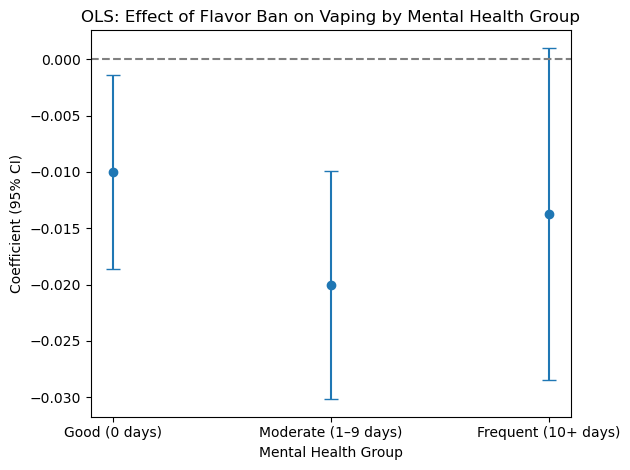

In [45]:
#OLS plot

ordered_groups = ['Good (0 days)', 'Moderate (1–9 days)', 'Frequent (10+ days)']

ols_coefs = []
ols_errs = []
labels = []

for group in ordered_groups:
    model = ols_results[group]
    coef = model.params['flavor_ban']
    stderr = model.bse['flavor_ban']
    ols_coefs.append(coef)
    ols_errs.append(stderr)
    labels.append(group)

plt.errorbar(labels, ols_coefs, yerr=1.96 * np.array(ols_errs), fmt='o', capsize=5)
plt.axhline(0, color='gray', linestyle='--')
plt.title('OLS: Effect of Flavor Ban on Vaping by Mental Health Group')
plt.ylabel('Coefficient (95% CI)')
plt.xlabel('Mental Health Group')
plt.tight_layout()
plt.show()


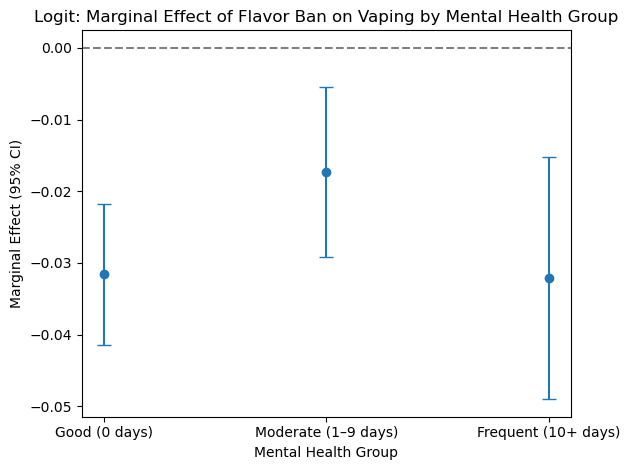

In [47]:
#logit
ordered_groups = ['Good (0 days)', 'Moderate (1–9 days)', 'Frequent (10+ days)']

logit_coefs = []
logit_errs = []
labels = []

for group in ordered_groups:
    marg = logit_results[group]
    coef = marg.loc['flavor_ban', 'dy/dx']
    stderr = marg.loc['flavor_ban', 'Std. Err.']
    logit_coefs.append(coef)
    logit_errs.append(stderr)
    labels.append(group)

# Plotting
plt.errorbar(labels, logit_coefs, yerr=1.96 * np.array(logit_errs), fmt='o', capsize=5)
plt.axhline(0, color='gray', linestyle='--')
plt.title('Logit: Marginal Effect of Flavor Ban on Vaping by Mental Health Group')
plt.ylabel('Marginal Effect (95% CI)')
plt.xlabel('Mental Health Group')
plt.tight_layout()
plt.show()


In [66]:
model_ment_interact_ols = smf.wls(
    'vapenow ~ flavor_ban * C(mh_group) + C(_STATE) + C(survey_year) + _AGE80 + C(SEXVAR) + C(_RACE) + unemp + Death + t21 + tax + ecig_tax + covid_dummy + rec_marijuana + post_ecig_indoor_ban',
    data=ment_df, weights=ment_df['LLCPWT']).fit()
print(model_ment_interact_ols.summary())

                            WLS Regression Results                            
Dep. Variable:                vapenow   R-squared:                       0.029
Model:                            WLS   Adj. R-squared:                  0.029
Method:                 Least Squares   F-statistic:                     71.08
Date:                Thu, 31 Jul 2025   Prob (F-statistic):               0.00
Time:                        15:07:55   Log-Likelihood:                -82737.
No. Observations:              184026   AIC:                         1.656e+05
Df Residuals:                  183947   BIC:                         1.664e+05
Df Model:                          78                                         
Covariance Type:            nonrobust                                         
                                                    coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------------

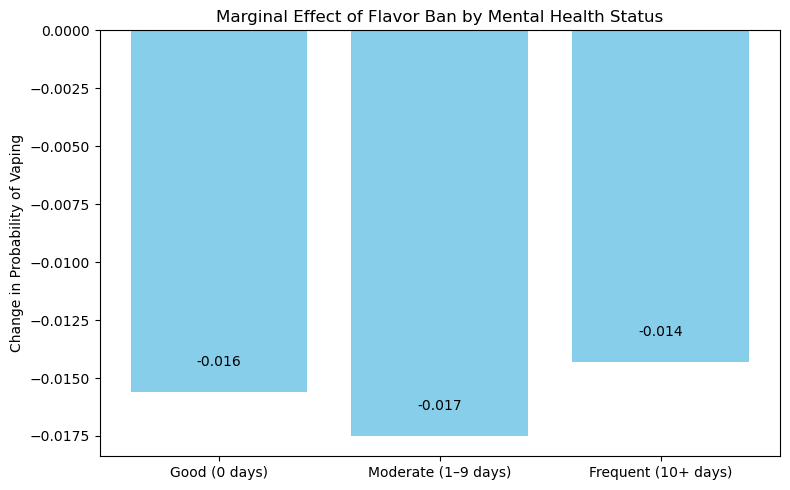

In [ ]:
# Get summary as DataFrame
marg_df = model_ment_interact_ols.summary2().tables[1]

# Extract coefficients
base = marg_df.loc['flavor_ban', 'Coef.']
moderate_coef = marg_df.loc['flavor_ban:C(mh_group)[T.Moderate (1–9 days)]', 'Coef.']
frequent_coef = marg_df.loc['flavor_ban:C(mh_group)[T.Frequent (10+ days)]', 'Coef.']

effects = [
    base,
    base + moderate_coef,
    base + frequent_coef
]

# Standard errors
base_se = marg_df.loc['flavor_ban', 'Std.Err.']
moderate_se = marg_df.loc['flavor_ban:C(mh_group)[T.Moderate (1–9 days)]', 'Std.Err.']
frequent_se = marg_df.loc['flavor_ban:C(mh_group)[T.Frequent (10+ days)]', 'Std.Err.']

errors = [
    base_se,
    np.sqrt(base_se**2 + moderate_se**2),
    np.sqrt(base_se**2 + frequent_se**2)
]

groups = ['Good (0 days)', 'Moderate (1–9 days)', ' (10+ days)']

# Plot
plt.figure(figsize=(8, 5))
plt.errorbar(groups, effects, yerr=1.96 * np.array(errors), fmt='o', capsize=5, label='Marginal Effect by Group')
plt.axhline(0, color='gray', linestyle='--')
plt.axhline(base, color='red', linestyle='--', label='Baseline Flavor Ban Effect\n(Good MH group)')
plt.ylabel('Change in Vaping Probability (95% CI)')
plt.xlabel('Mental Health Group')
plt.title('Interaction Effects of Flavor Ban by Mental Health')
plt.legend()
plt.tight_layout()
plt.show()



In [71]:
# Convert to dummies and interact with flavor_ban
model_ment_interact = smf.logit(
    'vapenow ~ flavor_ban * C(mh_group) + C(_STATE) + C(survey_year) + _AGE80 + C(SEXVAR) + C(_RACE) + unemp + Death + t21 + tax + ecig_tax + covid_dummy + rec_marijuana + post_ecig_indoor_ban',
    data=ment_df
).fit()

print(model_ment_interact.summary())

Optimization terminated successfully.
         Current function value: 0.286486
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:                vapenow   No. Observations:               184026
Model:                          Logit   Df Residuals:                   183947
Method:                           MLE   Df Model:                           78
Date:                Thu, 31 Jul 2025   Pseudo R-squ.:                 0.04185
Time:                        15:27:27   Log-Likelihood:                -52721.
converged:                       True   LL-Null:                       -55024.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                                    coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------------------
Intercept                             

In [52]:
marg = model_ment_interact.get_margeff(at='overall', method='dydx')
print(marg.summary())

        Logit Marginal Effects       
Dep. Variable:                vapenow
Method:                          dydx
At:                           overall
                                                   dy/dx    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------------------
C(mh_group)[T.Moderate (1–9 days)]                0.0052      0.002      2.790      0.005       0.002       0.009
C(mh_group)[T.Frequent (10+ days)]                0.0576      0.002     33.540      0.000       0.054       0.061
C(_STATE)[T.2]                                   -0.0368      0.010     -3.733      0.000      -0.056      -0.017
C(_STATE)[T.4]                                   -0.0050      0.011     -0.460      0.645      -0.026       0.016
C(_STATE)[T.5]                                   -0.0036      0.012     -0.308      0.758      -0.026       0.019
C(_STATE)[T.6]                                   -

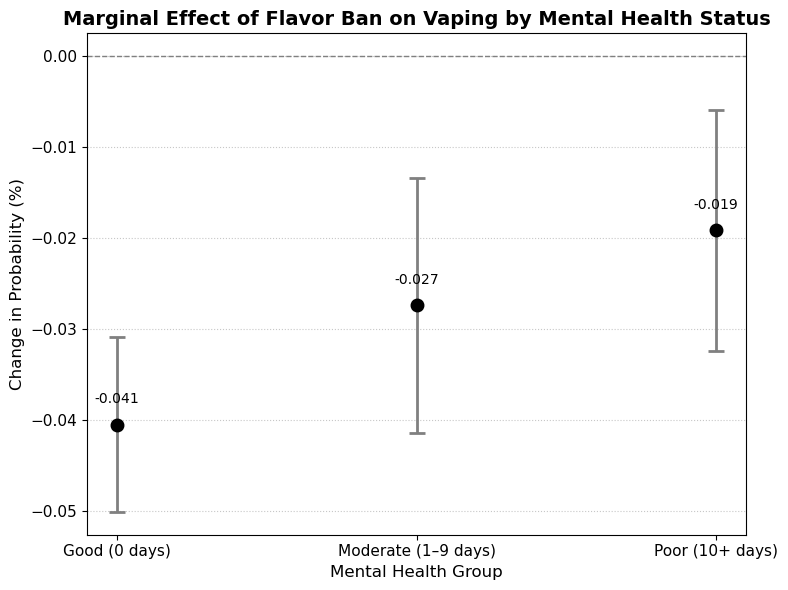

In [74]:
marg_df = marg.summary_frame()

# Inputs (same as your structure)
groups = ['Good (0 days)', 'Moderate (1–9 days)', 'Poor (10+ days)']
effects = [
    marg_df.loc['flavor_ban', 'dy/dx'],
    marg_df.loc['flavor_ban:C(mh_group)[T.Moderate (1–9 days)]', 'dy/dx'] + marg_df.loc['flavor_ban', 'dy/dx'],
    marg_df.loc['flavor_ban:C(mh_group)[T.Frequent (10+ days)]', 'dy/dx'] + marg_df.loc['flavor_ban', 'dy/dx']
]
errors = [
    marg_df.loc['flavor_ban', 'Std. Err.'],
    np.sqrt(marg_df.loc['flavor_ban', 'Std. Err.']**2 + marg_df.loc['flavor_ban:C(mh_group)[T.Moderate (1–9 days)]', 'Std. Err.']**2),
    np.sqrt(marg_df.loc['flavor_ban', 'Std. Err.']**2 + marg_df.loc['flavor_ban:C(mh_group)[T.Frequent (10+ days)]', 'Std. Err.']**2)
]

# Plot
fig, ax = plt.subplots(figsize=(8, 6))
ax.errorbar(groups, effects, yerr=1.96 * np.array(errors), fmt='o', 
            capsize=6, elinewidth=2, markeredgewidth=2, markersize=8, color='black', ecolor='gray')

# Aesthetic improvements
ax.axhline(0, color='gray', linestyle='--', linewidth=1)
ax.set_title('Marginal Effect of Flavor Ban on Vaping by Mental Health Status', fontsize=14, fontweight='bold')
ax.set_ylabel('Change in Probability (%)', fontsize=12)
ax.set_xlabel('Mental Health Group', fontsize=12)
ax.set_xticks(np.arange(len(groups)))
ax.set_xticklabels(groups, fontsize=11)
ax.tick_params(axis='y', labelsize=11)
ax.grid(axis='y', linestyle=':', alpha=0.7)

# Optional: add numerical labels for effect sizes
for i, (y, err) in enumerate(zip(effects, errors)):
    ax.text(i, y + 0.002, f'{y:.3f}', ha='center', va='bottom', fontsize=10, color='black')

plt.tight_layout()
plt.show()


In [59]:
#smoking logit
model_ment_sm_vars = [
    '_RFSMOK3', 'flavor_ban', 'SEXVAR', '_RACE', '_AGE80', 'MENTHLTH',
    'unemp', 'Death', 't21', 'tax', 'ecig_tax', 'covid_dummy',
    'rec_marijuana', 'post_ecig_indoor_ban', '_STATE', 'survey_year', 'LLCPWT', 'mh_group'
]
ment_sm_df = df[model_ment_sm_vars].dropna()

logit_model_g3_interact = smf.logit(
    formula = '_RFSMOK3 ~ flavor_ban * C(mh_group) + C(SEXVAR) + C(_RACE) + _AGE80 + MENTHLTH + unemp + Death + t21 + tax + ecig_tax + covid_dummy + rec_marijuana + post_ecig_indoor_ban + C(_STATE) + C(survey_year)',
    data=ment_sm_df  # same df as WLS
).fit()

print(logit_model_g3_interact.summary())

Optimization terminated successfully.
         Current function value: 0.370386
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:               _RFSMOK3   No. Observations:               183134
Model:                          Logit   Df Residuals:                   183054
Method:                           MLE   Df Model:                           79
Date:                Sun, 27 Jul 2025   Pseudo R-squ.:                  0.1433
Time:                        18:05:34   Log-Likelihood:                -67830.
converged:                       True   LL-Null:                       -79176.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                                    coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------------------
Intercept                             

In [75]:
marg_sm_ment = logit_model_g3_interact.get_margeff(at='overall', method='dydx')
print(marg_sm_ment.summary())

        Logit Marginal Effects       
Dep. Variable:               _RFSMOK3
Method:                          dydx
At:                           overall
                                                   dy/dx    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------------------
C(mh_group)[T.Moderate (1–9 days)]               -0.0290      0.002    -13.223      0.000      -0.033      -0.025
C(mh_group)[T.Frequent (10+ days)]               -0.0268      0.004     -6.693      0.000      -0.035      -0.019
C(SEXVAR)[T.2]                                   -0.0311      0.002    -19.021      0.000      -0.034      -0.028
C(_RACE)[T.2.0]                                  -0.0287      0.003     -8.550      0.000      -0.035      -0.022
C(_RACE)[T.3.0]                                   0.0795      0.005     16.599      0.000       0.070       0.089
C(_RACE)[T.4.0]                                  -

In [62]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegressionCV

# Define your variables
lasso_model_vars = [
    'vapenow', 'flavor_ban', 'SEXVAR', '_RACE', '_AGE80', 'MENTHLTH',
    'unemp', 'Death', 't21', 'tax', 'ecig_tax', 'covid_dummy',
    'rec_marijuana', 'post_ecig_indoor_ban', '_STATE', 'survey_year'
]

# Drop NA
df_lasso = df[lasso_model_vars].dropna()

# One-hot encode categorical variables
X = pd.get_dummies(
    df_lasso.drop(columns='vapenow'),
    columns=['SEXVAR', '_RACE', '_STATE', 'survey_year'],
    drop_first=True
)
y = df_lasso['vapenow']

# Standardize predictors
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Run logistic regression with L1 penalty and cross-validation
lasso = LogisticRegressionCV(
    Cs=10,
    penalty='l1',
    solver='saga',
    cv=5,
    scoring='neg_log_loss',
    max_iter=5000,
    n_jobs=-1,
    refit=True
)
lasso.fit(X_scaled, y)

# Extract non-zero coefficients
coef_series = pd.Series(lasso.coef_[0], index=X.columns)
selected_vars = coef_series[coef_series != 0].sort_values(key=abs, ascending=False)

print("Selected variables with non-zero coefficients:")
print(selected_vars)

Selected variables with non-zero coefficients:
MENTHLTH            0.287641
SEXVAR_2           -0.101488
_RACE_2.0          -0.086456
_RACE_8.0          -0.073742
_AGE80             -0.052409
survey_year_2020    0.014366
_RACE_4.0          -0.013434
tax                -0.001049
dtype: float64


In [76]:
model_g3_interact = smf.wls(
    formula = '_RFSMOK3 ~ flavor_ban * C(mh_group) + C(SEXVAR) + C(_RACE) + _AGE80 + MENTHLTH + unemp + Death + t21 + tax + ecig_tax + covid_dummy + rec_marijuana + post_ecig_indoor_ban + C(_STATE) + C(survey_year)',
    data=ment_sm_df, weights=ment_sm_df['LLCPWT']  # same df as WLS
).fit()

print(model_g3_interact.summary())

                            WLS Regression Results                            
Dep. Variable:               _RFSMOK3   R-squared:                       0.126
Model:                            WLS   Adj. R-squared:                  0.126
Method:                 Least Squares   F-statistic:                     334.1
Date:                Thu, 31 Jul 2025   Prob (F-statistic):               0.00
Time:                        15:59:24   Log-Likelihood:            -1.1660e+05
No. Observations:              183134   AIC:                         2.334e+05
Df Residuals:                  183054   BIC:                         2.342e+05
Df Model:                          79                                         
Covariance Type:            nonrobust                                         
                                                    coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------------

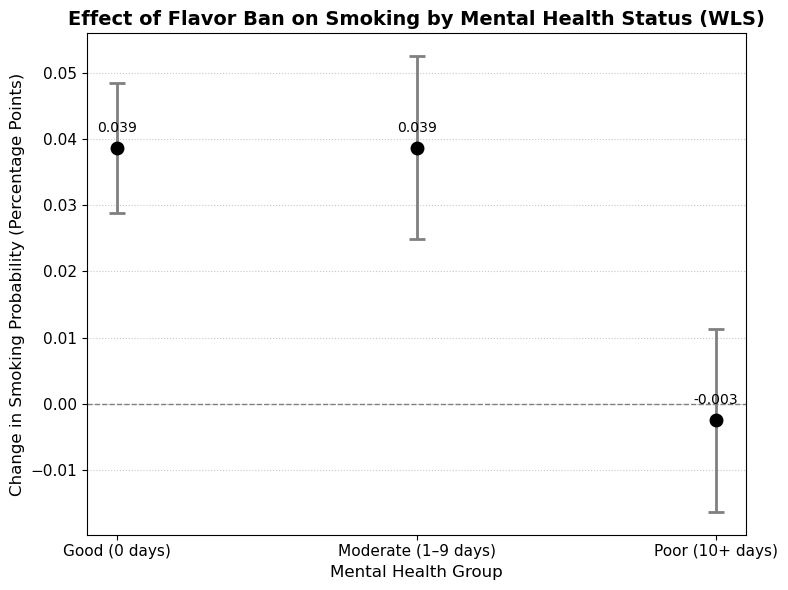

In [78]:
# Coefficients from your WLS model
coef_flavorban = 0.0387
coef_moderate = -9.384e-09  # essentially zero
coef_frequent = -0.0412

# Standard errors
se_flavorban = 0.005
se_moderate = 0.005
se_frequent = 0.005

# Group names
groups = ['Good (0 days)', 'Moderate (1–9 days)', 'Poor (10+ days)']

# Effects = main effect + interaction (if any)
effects = [
    coef_flavorban,
    coef_flavorban + coef_moderate,
    coef_flavorban + coef_frequent
]

# Standard errors for combined effects (assuming zero covariance)
errors = [
    se_flavorban,
    np.sqrt(se_flavorban**2 + se_moderate**2),
    np.sqrt(se_flavorban**2 + se_frequent**2)
]

# Plot
fig, ax = plt.subplots(figsize=(8, 6))
ax.errorbar(groups, effects, yerr=1.96 * np.array(errors), fmt='o',
            capsize=6, elinewidth=2, markeredgewidth=2, markersize=8, color='black', ecolor='gray')

# Aesthetic tweaks
ax.axhline(0, color='gray', linestyle='--', linewidth=1)
ax.set_title('Effect of Flavor Ban on Smoking by Mental Health Status (WLS)', fontsize=14, fontweight='bold')
ax.set_ylabel('Change in Smoking Probability (Percentage Points)', fontsize=12)
ax.set_xlabel('Mental Health Group', fontsize=12)
ax.set_xticks(np.arange(len(groups)))
ax.set_xticklabels(groups, fontsize=11)
ax.tick_params(axis='y', labelsize=11)
ax.grid(axis='y', linestyle=':', alpha=0.7)

# Add text labels
for i, (y, err) in enumerate(zip(effects, errors)):
    ax.text(i, y + 0.002, f'{y:.3f}', ha='center', va='bottom', fontsize=10, color='black')

plt.tight_layout()
plt.show()
